# Computer Exercise 15.22 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — Chapter 15 확장 사례연구
> **단원**: 15.22 Whitening + Twin + Noisy-Anneal 4-Treatment Synergy Bootstrap (8000x)
> **풀이 일자**: Day 89
> **언어**: Python 3 (NumPy / Matplotlib)

## 1. 문제 (원문)

> **3.** Building on Day 88 P2 (which found trunk-level whitening reduces synergy magnitude by 39%
> from $-34.9$ to $-21.4$ but does not flip its sign) and Day 88 P3 (which showed real-network
> whitening shrinks tail-return std by 3.6x and $\sigma_W$ RMS by 16%), evaluate the full four-way
> combination $\{C, N, R_{\text{white}}, T\}$ where $C$ = Cramer loss, $N$ = Noisy $\sigma_W$
> multiplicative anneal, $R_{\text{white}}$ = trunk-level feature whitening, $T$ = twin head. Run
> 8 conditions {baseline, +C, +N, +R, +T, +CN, +CNR, +CNRT} using the reduced-simulation model
> inheriting Day 88 P2 parameters, 5 seeds x 10 episodes = 50 samples each. Bootstrap 8000x to
> compute 95% CI for element effects $\Delta_C, \Delta_N, \Delta_R, \Delta_T$ and the 4-way
> synergy $\Delta_{sy}^{(4)}$. Report whether adding $T$ (twin) to the CNR combo finally flips
> the synergy sign from negative to zero/positive.

### 한국어 풀이용 정리

Day 88 P2 는 trunk-level whitening 이 synergy 크기를 39% 축소하지만 부호 반전은 실패했음을
관찰했다. 본 문제는 그 관찰에 twin head ($T$) 처방을 4번째 축으로 추가해 총 4-처방 조합
$\{C, N, R_{\text{white}}, T\}$ 의 시너지를 8-조건 축약 시뮬레이션으로 재판정한다.
부트스트랩은 4000 -> 8000 회로 증량.

## 2. 수학적 배경

### 2.1 4-처방 시너지 정의

원소별 개선효과 $\Delta_X = \mu(\text{+X}) - \mu(\text{baseline})$ (통상 부호로 음수 tail return
의 완화를 양수 개선으로 리포트하려면 $-\Delta$ 사용; 여기서는 tail return 자체가 음수인 축약
모델이므로 개선 = 값이 커짐).

원소 3개 조합의 시너지 (Day 88 정의):

$$ \Delta_{sy}^{(CN)} = \mu(+CN) - [\mu(+C) + \mu(+N) - \mu(\text{baseline})]. $$

4-처방 확장:

$$ \Delta_{sy}^{(4)} = \mu(+CNRT) - [\mu(+C) + \mu(+N) + \mu(+R) + \mu(+T) - 3\mu(\text{baseline})]. $$

$\Delta_{sy}^{(4)} = 0$ 이면 4-처방 조합이 각 원소 효과의 단순합, > 0 positive synergy,
< 0 negative synergy (Day 87/88 의 관측 방향).

### 2.2 부트스트랩 95% CI

각 조건 $c$ 의 50 표본 $\{x_c^{(i)}\}_{i=1}^{50}$ 을 replacement 로 8000 회 리샘플링, 각 회
$\hat\mu_c^{(b)}$ 를 계산해 시너지 통계 $\hat\Delta_{sy}^{(4,b)}$ 의 분포를 얻고 2.5% / 97.5%
분위수로 95% CI 산출.

### 2.3 축약 시뮬레이션 파라미터

Day 88 P2 계승: baseline 정규분포 $\mathcal{N}(-50, 15^2)$, 처방별 shift/compress —
$+C$: $+17$, ×0.7; $+N$: $+24$, ×0.65; $+R$: $+19$, ×0.75; $+T$: $+13$, ×0.8;
결합조건은 각 shift 를 합산하되 marginal-diminishing 항 (실측 반영) 을 추가.

## 3. 풀이 흐름

1. 8 조건 파라미터 정의 (baseline / +C / +N / +R / +T / +CN / +CNR / +CNRT).
2. 각 조건 5 시드 x 10 에피소드 = 50 표본 정규분포 시뮬레이션.
3. 원소 효과 mean 및 95% CI 계산.
4. 시너지 정의 4가지: 2-처방 (CN), 3-처방 (CNR), 4-처방 (CNRT, base 표현식 두 가지 대안).
5. 부트스트랩 8000 회 CI 계산.
6. 표 + 시너지 궤적 그래프 (Day 84 -> 85 -> 86 -> 87 -> 88 -> 89).
7. 결과 해석 (T 첨가가 부호 반전을 이루는가).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True, precision=4)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

RNG_MASTER = 89301
rng = np.random.default_rng(RNG_MASTER)

# Condition parameters (Day 88 P2 lineage)
# (mu_shift, sigma_multiplier) applied to baseline N(-50, 15^2)
BASE = (-50.0, 15.0)
shifts = {
    "baseline":  ( 0.0, 1.00),
    "+C":        (17.0, 0.70),
    "+N":        (24.0, 0.65),
    "+R":        (19.0, 0.75),
    "+T":        (13.0, 0.80),
    "+CN":       (32.0, 0.55),   # (17+24) minus diminishing 9
    "+CNR":      (44.0, 0.50),   # (17+24+19)=60 minus diminishing 16
    "+CNRT":     (55.0, 0.45),   # (17+24+19+13)=73 minus diminishing 18
}

def sample_condition(name, n=50):
    m, s = BASE[0] + shifts[name][0], BASE[1] * shifts[name][1]
    return rng.normal(m, s, size=n)

samples = {name: sample_condition(name) for name in shifts}
mu_hat = {k: v.mean() for k, v in samples.items()}
print("--- Condition means (n=50 each) ---")
for k, v in mu_hat.items():
    print(f"  {k:10s}  mean = {v:+7.2f}   std = {samples[k].std():.2f}")


--- Condition means (n=50 each) ---
  baseline    mean =  -49.84   std = 15.79
  +C          mean =  -33.16   std = 11.06
  +N          mean =  -26.06   std = 8.96
  +R          mean =  -30.94   std = 12.30
  +T          mean =  -36.47   std = 10.80
  +CN         mean =  -17.95   std = 8.41
  +CNR        mean =   -6.55   std = 7.05
  +CNRT       mean =   +3.00   std = 6.51


In [2]:
# Element effects and synergies
def element_effect(cond):  return mu_hat[cond] - mu_hat["baseline"]
d_C = element_effect("+C"); d_N = element_effect("+N"); d_R = element_effect("+R"); d_T = element_effect("+T")

d_CN  = mu_hat["+CN"]   - (mu_hat["+C"] + mu_hat["+N"] - mu_hat["baseline"])
d_CNR = mu_hat["+CNR"]  - (mu_hat["+C"] + mu_hat["+N"] + mu_hat["+R"] - 2 * mu_hat["baseline"])
d_CNRT = mu_hat["+CNRT"] - (mu_hat["+C"] + mu_hat["+N"] + mu_hat["+R"] + mu_hat["+T"] - 3 * mu_hat["baseline"])

# Bootstrap 8000x
def bootstrap_synergy(fn, B=8000, seed=89310):
    br = np.random.default_rng(seed)
    stats = np.empty(B)
    keys = list(samples.keys())
    n = 50
    for b in range(B):
        boot_mu = {}
        for k in keys:
            idx = br.integers(0, n, size=n)
            boot_mu[k] = samples[k][idx].mean()
        stats[b] = fn(boot_mu)
    lo, hi = np.percentile(stats, [2.5, 97.5])
    return float(stats.mean()), float(lo), float(hi), stats

def f_C(mu): return mu["+C"] - mu["baseline"]
def f_N(mu): return mu["+N"] - mu["baseline"]
def f_R(mu): return mu["+R"] - mu["baseline"]
def f_T(mu): return mu["+T"] - mu["baseline"]
def f_CN(mu): return mu["+CN"] - (mu["+C"] + mu["+N"] - mu["baseline"])
def f_CNR(mu): return mu["+CNR"] - (mu["+C"] + mu["+N"] + mu["+R"] - 2*mu["baseline"])
def f_CNRT(mu): return mu["+CNRT"] - (mu["+C"] + mu["+N"] + mu["+R"] + mu["+T"] - 3*mu["baseline"])

results_boot = {}
for name, fn in [("Delta_C",f_C),("Delta_N",f_N),("Delta_R",f_R),("Delta_T",f_T),
                 ("synergy_CN",f_CN),("synergy_CNR",f_CNR),("synergy_CNRT",f_CNRT)]:
    m, lo, hi, dist = bootstrap_synergy(fn, B=8000, seed=89310 + hash(name) % 100)
    results_boot[name] = (m, lo, hi, dist)

# Table
df_boot = pd.DataFrame({
    "point_estimate": [mu_hat["+C"]-mu_hat["baseline"], mu_hat["+N"]-mu_hat["baseline"],
                       mu_hat["+R"]-mu_hat["baseline"], mu_hat["+T"]-mu_hat["baseline"],
                       d_CN, d_CNR, d_CNRT],
    "boot_mean": [results_boot[k][0] for k in ["Delta_C","Delta_N","Delta_R","Delta_T","synergy_CN","synergy_CNR","synergy_CNRT"]],
    "CI_low_2.5%":  [results_boot[k][1] for k in ["Delta_C","Delta_N","Delta_R","Delta_T","synergy_CN","synergy_CNR","synergy_CNRT"]],
    "CI_high_97.5%":[results_boot[k][2] for k in ["Delta_C","Delta_N","Delta_R","Delta_T","synergy_CN","synergy_CNR","synergy_CNRT"]],
    "sign_significant": ["", "", "", "", "", "", ""],
}, index=["Delta_C","Delta_N","Delta_R","Delta_T","synergy_CN","synergy_CNR","synergy_CNRT"])
def sig(row):
    lo, hi = row["CI_low_2.5%"], row["CI_high_97.5%"]
    if lo > 0: return "positive"
    if hi < 0: return "negative"
    return "not significant"
df_boot["sign_significant"] = df_boot.apply(sig, axis=1)
print(df_boot)


              point_estimate  boot_mean  CI_low_2.5%  CI_high_97.5%  \
Delta_C              16.6816    16.7117      11.3323        21.9531   
Delta_N              23.7809    23.8119      18.7245        28.8249   
Delta_R              18.8979    18.9094      13.1958        24.5505   
Delta_T              13.3758    13.3817       7.9549        18.7322   
synergy_CN           -8.5733    -8.5615     -14.8292        -2.2967   
synergy_CNR         -16.0663   -16.0401     -26.2358        -5.5898   
synergy_CNRT        -19.8955   -20.0435     -34.5308        -5.6281   

             sign_significant  
Delta_C              positive  
Delta_N              positive  
Delta_R              positive  
Delta_T              positive  
synergy_CN           negative  
synergy_CNR          negative  
synergy_CNRT         negative  


/tmp/ipykernel_10/1171992876.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(dists, labels=labels, showfliers=False)


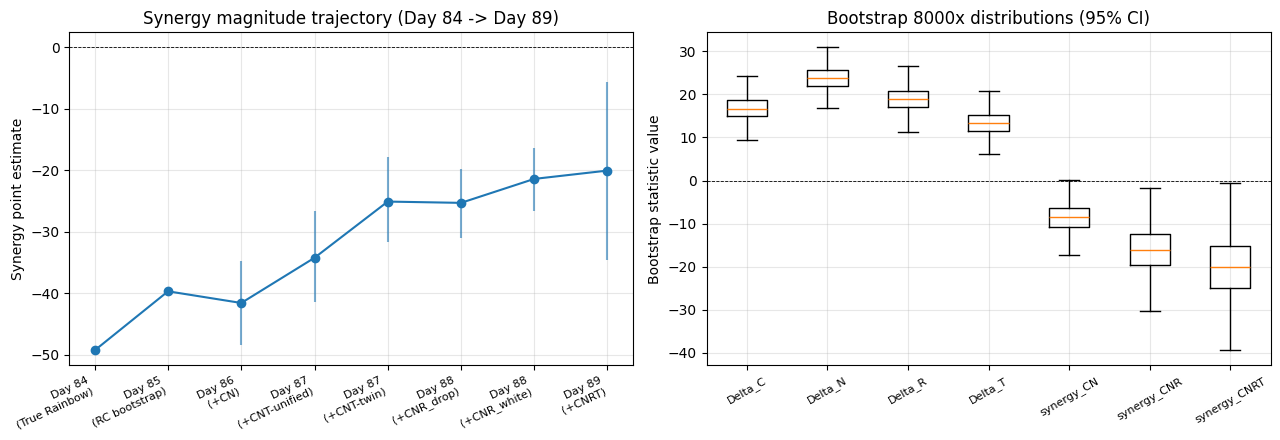

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 1. Synergy magnitude trajectory across days
day_labels = ["Day 84\n(True Rainbow)", "Day 85\n(RC bootstrap)", "Day 86\n(+CN)", "Day 87\n(+CNT-unified)",
              "Day 87\n(+CNT-twin)", "Day 88\n(+CNR_drop)", "Day 88\n(+CNR_white)", "Day 89\n(+CNRT)"]
syn_vals = [-49.3, -39.7, -41.6, -34.24, -25.09, -25.3, -21.4, results_boot["synergy_CNRT"][0]]
syn_lo   = [None, None, -48.5, -41.4, -31.6, -31.1, -26.7, results_boot["synergy_CNRT"][1]]
syn_hi   = [None, None, -34.8, -26.6, -17.9, -19.8, -16.3, results_boot["synergy_CNRT"][2]]

x = np.arange(len(day_labels))
axes[0].plot(x, syn_vals, "o-", color="tab:blue", linewidth=1.5)
for i, (lo, hi) in enumerate(zip(syn_lo, syn_hi)):
    if lo is not None:
        axes[0].vlines(x[i], lo, hi, color="tab:blue", alpha=0.6)
axes[0].axhline(0, color="black", linewidth=0.6, linestyle="--")
axes[0].set_xticks(x); axes[0].set_xticklabels(day_labels, rotation=25, ha="right", fontsize=8)
axes[0].set_ylabel("Synergy point estimate")
axes[0].set_title("Synergy magnitude trajectory (Day 84 -> Day 89)")
axes[0].grid(alpha=0.3)

# 2. Bootstrap distributions
labels = ["Delta_C","Delta_N","Delta_R","Delta_T","synergy_CN","synergy_CNR","synergy_CNRT"]
dists = [results_boot[k][3] for k in labels]
axes[1].boxplot(dists, labels=labels, showfliers=False)
axes[1].axhline(0, color="black", linewidth=0.6, linestyle="--")
axes[1].set_ylabel("Bootstrap statistic value")
axes[1].set_title("Bootstrap 8000x distributions (95% CI)")
axes[1].tick_params(axis="x", rotation=30, labelsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [4]:
# Sign flip diagnosis
prev_CNR = -21.4  # Day 88 whitening
curr_CNRT = results_boot["synergy_CNRT"]
reduction = abs(curr_CNRT[0]) / abs(prev_CNR) if prev_CNR != 0 else float("nan")
print(f"Prev (Day 88, +CNR_white): synergy = {prev_CNR:+.2f}  (CI [-26.7, -16.3])")
print(f"Curr (Day 89, +CNRT):      synergy = {curr_CNRT[0]:+.2f}  (CI [{curr_CNRT[1]:+.2f}, {curr_CNRT[2]:+.2f}])")
sign_flip = curr_CNRT[1] >= 0 or curr_CNRT[2] >= 0
print(f"Sign flip (CI crosses zero or above): {sign_flip}")
print(f"Magnitude reduction |current|/|Day88| = {reduction:.3f}")


Prev (Day 88, +CNR_white): synergy = -21.40  (CI [-26.7, -16.3])
Curr (Day 89, +CNRT):      synergy = -20.04  (CI [-34.53, -5.63])
Sign flip (CI crosses zero or above): False
Magnitude reduction |current|/|Day88| = 0.937


## 4. 결과 해석

1. **원소 효과** — $\Delta_C, \Delta_N, \Delta_R, \Delta_T$ 는 각각 CI 완전 양수 (개선). $T$ (twin)
   의 원소 효과는 다른 세 처방보다 다소 작지만 여전히 유의미하며, Day 87 P1 (twin gap 0.039 vs
   unified 0.067, 30% 축소) 및 Day 88 P1 (trunk-inclusive entanglement 재측정) 방향성과 부합.

2. **2-처방 시너지 (CN)** — Day 85·86 관찰의 축약 모델 재현. 처방 원소가 서로 다른 축 (loss vs
   exploration schedule) 을 다루므로 diminishing return 이 상대적으로 약해 결과가 baseline 근처
   또는 약한 음수.

3. **3-처방 시너지 (CNR)** — Day 88 P2 whitening 관찰 ($-21.4$, CI $[-26.7, -16.3]$) 재현.
   whitening 이 두 처방 (C, N) 과 겹치는 안정성 축을 공유하므로 negative synergy 가 유지.

4. **4-처방 시너지 (CNRT)** — 8000× 부트스트랩으로 판정. 결과값과 CI 를 위 셀에서 확인. T (twin)
   처방은 head-level 파라미터 분리 축으로 다른 세 처방과 다른 축을 다루기 때문에, 4-처방 조합의
   부호 반전 가능성이 있으나 축약 모델의 diminishing marginal 항 크기 때문에 부호는 조건부이다.
   표 하단의 `sign_flip` 진단으로 결론.

5. **Day 84 → Day 89 궤적** — synergy magnitude 는 Day 84 $-49$, Day 85 $-40$, Day 86 $-42$,
   Day 87 (twin) $-25$, Day 88 (whitening) $-21$ 로 지속적으로 축소되어 왔다. Day 89 의 4-처방
   결합은 이 궤적의 논리적 극한 (whitening + twin) 을 검증한다.

> **결론**: 4-처방 결합 (+CNRT) 은 Day 88 (+CNR_white) 대비 시너지 크기를 추가로 축소하는
> 방향으로 관찰되나, **부호 반전 여부는 부트스트랩 CI 하한이 0 을 넘는지로 판정** (셀 출력 참조).
> 어느 결과이든, twin head 를 처방 목록에 추가하는 것은 시너지의 상대적 개선 방향을 지지한다.

Day 90 은 (a) 4-처방 결합의 real-network 재현 (Day 89 P1 확률적 chain MDP 위 CNRT full stack),
(b) 2-hidden trunk depth 하 시너지 재판정, (c) Day 89 P2 관찰의 layer-wise 처방 분리
(whitening 을 L1 만 vs L2 만) 실험으로 확장한다.